In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from scipy.stats import moment
from scipy import stats
import matplotlib.colors as mcolors

from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import calendar
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle
import cartopy.crs as ccrs
import cartopy.feature as cfeature







from pylab import rcParams
rcParams['axes.labelweight'] = 'normal'
rcParams['axes.labelsize'] = 'x-large'
rcParams['axes.titlesize'] = 'xx-large'
rcParams['axes.titleweight'] = 'normal'

In [2]:
def decode_time(filepath):
    ds = xr.open_dataset(filepath, decode_times=False)
    units, reference_date = ds.time.attrs['units'].split('since')
    ds['time'] = pd.date_range(start=reference_date, periods=ds.sizes['time'], freq='MS')
    return ds


# Define constants
p0 = 1000  # reference pressure in hPa
R = 287.05  # specific gas constant for dry air in J/(kg*K)
cp = 1005  # specific heat at constant pressure for dry air in J/(kg*K)

def convert_to_potential_temperature(T, p):
    """
    Convert temperature to potential temperature.
    
    Parameters:
    T (xarray.DataArray): Temperature in K
    p (xarray.DataArray): Pressure in hPa
    
    Returns:
    xarray.DataArray: Potential temperature in K
    """
    return T * (p0 / p) ** (R / cp)


## T500 Jump

# T500

In [3]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', '2023'), lat = slice(25, -15)).sel(plev = 50000)
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])


In [4]:
#convert to potential temperature
t500 = convert_to_potential_temperature(t500, 500)

In [5]:
#ASO season
t500_aso = t500.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()



In [6]:
dt = t500_aso - t500_aso.roll(year  = 1)
dt = dt.drop_isel(year = 1)

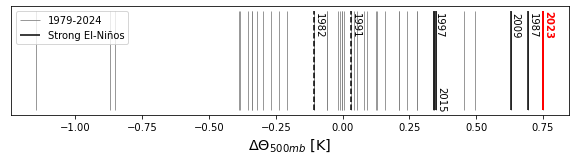

In [7]:
# Assuming dt.ocean_mean and dt.year exist


composite_years = [1982, 1987, 1991, 1997, 2015, 2009]
dt_composite = dt.where(dt.year.isin([composite_years]), drop = True)

# Create a figure
fig, ax = plt.subplots(figsize=(10, 2))

# Plot all years in grey
ax.vlines(dt.ocean_mean, ymin=0, ymax=1, color='grey', linewidth=0.8, label = '1979-2024')

# Plot composite years in black
ax.vlines(dt.sel(year = 1982).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1987).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 1991).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5, linestyle = '--')
ax.vlines(dt.sel(year = 1997).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2009).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)
ax.vlines(dt.sel(year = 2015).ocean_mean, ymin=0, ymax=1, color='black', linewidth=1.5)


for y in dt_composite.year.values: 

    if y == 2015: 
        x = dt.sel(year = y).ocean_mean
        ax.annotate(y, (x, 0.), rotation = 270)
        continue
    x = dt.sel(year = y).ocean_mean
    ax.annotate(y, (x, 0.75), rotation = 270)        

x = dt.sel(year= 2023).ocean_mean
ax.vlines(x, ymin=0, ymax=1, color='red', linewidth=2)
ax.vlines(x, ymin=0, ymax = 0, color = 'k', linewidth = 1.5, label = 'Strong El-Niños')
ax.annotate(2023,  (x, 0.75), rotation = 270, fontweight = 'bold', color = 'r')


# Formatting
#ax.set_xticks(years[::5])  # Show every 5th year for readability
#ax.set_xlim(min(years) - 1, max(years) + 1)
ax.set_yticks([])
ax.set_xlabel(r"ΔΘ$_{500mb}$ [K]", fontweight = 'normal')
#ax.set_title("Barcode Plot of dt.ocean_mean")

plt.legend(loc = 'upper left')
fig.savefig('output/FigS6a.svg', bbox_inches='tight')
plt.show()




## Scatter Plot

In [8]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp)

In [9]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', None), lat = slice(25, -15)).sel(plev = 50000)

In [10]:
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])

clim = t500.sel(time = slice('1991', '2020')).ocean_mean.groupby('time.month').mean()
t500['anom'] = t500.ocean_mean.groupby('time.month') - clim


#convert
t500 = convert_to_potential_temperature(t500, p = 500)

t500 = t500.rolling(time = 3, center = True, min_periods = 1).mean()

In [11]:

from statsmodels.nonparametric.smoothers_lowess import lowess

def detrend_yearly_loess_full(s, frac=0.6):
    """
    Detrend a full time series using LOESS smoothing.
    
    Parameters:
        s (xr.DataArray): Input data with a 'year' coordinate.
        frac (float): Fraction of data used for LOESS smoothing (controls smoothness).
    
    Returns:
        xr.DataArray: Detrended data array.
    """
    # Extract years and values
    years = s.year.values
    values = s.values

    # Apply LOESS smoothing to the full dataset
    loess_fit = lowess(values, years, frac=frac, return_sorted=False)

    

    # Detrend the data
    detrended_values = values - loess_fit

    # Create a new DataArray for the detrended data
    detrended_data = xr.DataArray(
        detrended_values,
        coords={"year": years},
        dims="year"
    )
    return detrended_data


# T500

In [12]:
fp = '/data/jmex/ERA5/monthly/era5_t500.nc'
t500 = decode_time(fp).sel(time = slice('1979', '2023'), lat = slice(25, -15)).sel(plev = 50000)
weights = np.cos(np.deg2rad(t500.lat))

t500['ocean_mean'] = t500.t.weighted(weights).mean(['lat', 'lon'])


In [13]:
#convert to potential temperature
t500 = convert_to_potential_temperature(t500, 500)

In [14]:
#ASO season
t500_aso = t500.where(t500.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

clim = t500_aso.sel(year = slice('1991', '2020')).ocean_mean.mean('year')

#ASO anom
t500_aso['ocean_anom'] = t500_aso.ocean_mean - clim

In [15]:
t500_aso['det'] = detrend_yearly_loess_full(t500_aso.ocean_anom)

###  Ocean Mask

In [19]:
#load the masks
fp = '/data/jmex/masks/RECCAP2_region_masks_all.nc'
masks = xr.open_dataset(fp).sel(lat = slice(-15,25))
#ocean_mask = masks.open_ocean.isin([2,3]) # mask for tropical indo-pacifc
ocean_mask = masks.seamask ==1 # mask for all tropical ocean

## SST

In [20]:
#import sst
fp = '/data/jmex/ERA5/monthly/era5_sst.nc'
sst = decode_time(fp).sel(lat = slice(25,-15), time = slice('1979', '2023'))
#ocean_mask = ~sst.isel(time = 1).sst.isnull()
sst = sst.where(ocean_mask)

In [21]:
sst_aso = sst.where(sst.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

## TP

In [22]:
fp = '/data/jmex/NOAA/precip.mon.mean.nc'
tp = xr.open_dataset(fp).sel(lat = slice(-15,25), time = slice('1979','2023'))
tp = tp.drop_vars(['time_bnds', 'lat_bnds', 'lon_bnds']).rename({'precip':'tp'})

#tp aso only 

tp_aso = tp.where(tp.time.dt.month.isin([8,9,10])).groupby('time.year').mean()

In [23]:
#interp sst to match gpcp
sst_aso = sst_aso.interp(lat = tp.lat, lon = tp.lon, method = 'nearest')

#second ocean_mask, on the GPCP grid
#make ocean mask
ocean_mask2 = ~sst_aso.isel(year = 1).sst.isnull()


#take t for ocean mask only: 
tp_aso = tp_aso.where(ocean_mask2)

weights = np.cos(np.deg2rad(tp.lat))
tp_aso['ocean_mean'] = tp_aso.tp.weighted(weights).mean(['lat', 'lon'])

## PWS

In [24]:
pws_aso = xr.zeros_like(sst_aso)
pws_aso = pws_aso.rename({'sst': 'pws'})

In [25]:
pws_aso['pws'] = sst_aso.sst * tp_aso.tp/tp_aso.ocean_mean 

pws_aso['pws_mean'] = pws_aso.pws.weighted(weights).mean(['lat', 'lon'])
#subtract mean
pws_aso['pws_mean'] = pws_aso['pws_mean']-pws_aso.pws_mean.mean()

In [26]:
pws_aso['pws_detrended'] = detrend_yearly_loess_full(pws_aso.pws_mean)

## Regression

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import seaborn as sns

def plot_with_regression(ax, x, y, x_label, y_label, years, highlight_years=[], volc_years=[]):
    x = np.asarray(x)
    y = np.asarray(y)
    years = np.asarray(years)
    
    # Fit regression
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, y_pred)

    # Base scatter
    ax.scatter(x, y, c='lightgrey', s=40, label='_base')

    # Color palette for highlighted years
    color_palette = sns.color_palette("colorblind", len(highlight_years))
    year_color_map = dict(zip(highlight_years, color_palette))

    # Plot highlighted years and their previous years
    for i, yr in enumerate(highlight_years):
        idx = np.where(years == yr)[0][0]
        ax.scatter(x[idx], y[idx], color=year_color_map[yr], s=80, label=str(yr), zorder=3)

        # Mark the previous year
        prev_year = yr - 1
        if prev_year in years:
            prev_idx = np.where(years == prev_year)[0][0]
            ax.scatter(x[prev_idx], y[prev_idx], 
                       facecolor='lightgrey', edgecolor=year_color_map[yr], 
                       linewidth=2, s=60, zorder=2)

    # Highlight 2023
    if 2023 in years:
        idx_2023 = np.where(years == 2023)[0][0]
        idx_2022 = np.where(years == 2022)[0][0]

        # Plot 2023
        ax.scatter(x[idx_2023], y[idx_2023], c='black', s=80, label='2023', zorder=4)

        # Plot 2022
        ax.scatter(x[idx_2022], y[idx_2022], facecolor='lightgrey', edgecolor='black',
                   linewidth=2, s=60, label='2022/Year [-1]', zorder=4)

        # Draw arrow from 2022 to 2023
        ax.annotate(
            '',
            xy=(x[idx_2023], y[idx_2023]),
            xytext=(x[idx_2022], y[idx_2022]),
            arrowprops=dict(
                arrowstyle='->,head_length=2,head_width=1',  # smaller head
                linestyle='solid',#(0, (1, 5)),  
                color='black',
                lw=1.2  # slightly thinner
            ),
            zorder=3
        )


    # Volcanic years (black x)
    for j, volc_year in enumerate(volc_years):
        if volc_year in years:
            idx_volc = np.where(years == volc_year)[0][0]
            ax.scatter(x[idx_volc], y[idx_volc], c='black', s=100, marker='x', linewidths=2.0,
                       label='Volcanic' if j == 0 else None, zorder=1)

    # Regression line
    ax.plot(np.sort(x), np.sort(y_pred), color='dimgrey', linestyle='--', label=f'$R^2 = {r2:.2f}$')

    # Zero lines
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)

    # Aesthetic cleanup
    ax.yaxis.grid(False)
    ax.xaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Labels
    ax.set_xlabel(x_label, fontsize=20)
    ax.set_ylabel(y_label, fontsize=20)
    ax.tick_params(labelsize=14)
    ax.legend()

    print(r2)
    return y - y_pred  # residuals


0.7455737241718383


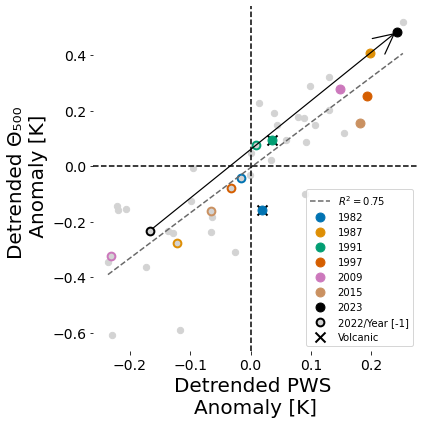

In [30]:
highlight_years = [1982, 1987, 1991, 1997, 2009, 2015]
volcanic_years = [1982, 1991]

fig, ax = plt.subplots(figsize=(6, 6))

residuals = plot_with_regression(
    ax,
    x=pws_aso.pws_detrended.values,
    y=t500_aso.det,
    x_label='Detrended PWS \nAnomaly [K]',
    y_label = 'Detrended Θ₅₀₀ \n Anomaly [K]',
    years=pws_aso.year.values,
    highlight_years=highlight_years,
    volc_years=volcanic_years
)

plt.tight_layout()
plt.show()
fig.savefig('output/FigS6b.svg', dpi = 600, bbox_inches='tight')

